In [ ]:
# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline


# A Gentle Introduction to ``torch.autograd``

``torch.autograd`` is PyTorch’s automatic differentiation engine that powers
neural network training. In this section, you will get a conceptual
understanding of how autograd helps a neural network train.

## Background
Neural networks (NNs) are a collection of nested functions that are
executed on some input data. These functions are defined by *parameters*
(consisting of weights and biases), which in PyTorch are stored in
tensors.

Training a NN happens in two steps:

**Forward Propagation**: In forward prop, the NN makes its best guess
about the correct output. It runs the input data through each of its
functions to make this guess.

**Backward Propagation**: In backprop, the NN adjusts its parameters
proportionate to the error in its guess. It does this by traversing
backwards from the output, collecting the derivatives of the error with
respect to the parameters of the functions (*gradients*), and optimizing
the parameters using gradient descent. For a more detailed walkthrough
of backprop, check out this [video from
3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8)_.




## Usage in PyTorch
Let's take a look at a single training step.
For this example, we load a pretrained resnet18 model from ``torchvision``.
We create a random data tensor to represent a single image with 3 channels, and height & width of 64,
and its corresponding ``label`` initialized to some random values. Label in pretrained models has
shape (1,1000).

In [ ]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT) # Also hier wird nicht der Architekturcode von ResNet18 ausgeführt, sondern die vortrainierten Gewichte auch
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\skmey/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 47.3MB/s]


*Warum macht man das?*

Debugging: Um zu sehen, ob der "Forward Pass" (Daten durch das Modell schicken) ohne Fehlermeldung durchläuft.

Dimensionen prüfen: Um sicherzustellen, dass die Ein- und Ausgangsformen (Shapes) der Daten zum Modell passen.

Dieses Bild soll die Dimensionen illustrieren :

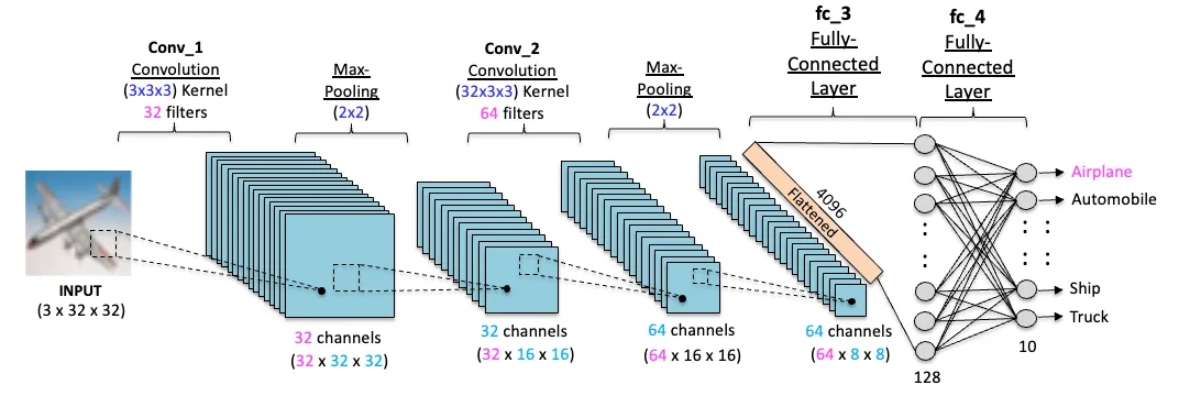

In [4]:
data

tensor([[[[0.7976, 0.7546, 0.9004,  ..., 0.8963, 0.4839, 0.7224],
          [0.8546, 0.8948, 0.3494,  ..., 0.9035, 0.9104, 0.9697],
          [0.8186, 0.4625, 0.8026,  ..., 0.2725, 0.3459, 0.2529],
          ...,
          [0.6766, 0.1686, 0.3981,  ..., 0.9495, 0.6634, 0.2750],
          [0.5608, 0.3171, 0.5082,  ..., 0.4830, 0.7418, 0.4686],
          [0.3721, 0.6156, 0.6719,  ..., 0.2746, 0.9168, 0.3080]],

         [[0.4119, 0.0577, 0.9572,  ..., 0.0314, 0.3423, 0.7177],
          [0.5203, 0.8338, 0.3257,  ..., 0.5202, 0.1137, 0.7667],
          [0.9981, 0.0662, 0.5574,  ..., 0.3141, 0.5007, 0.8380],
          ...,
          [0.8675, 0.5967, 0.3113,  ..., 0.4530, 0.1120, 0.4038],
          [0.7624, 0.0938, 0.3915,  ..., 0.4735, 0.4163, 0.7308],
          [0.6248, 0.4666, 0.5040,  ..., 0.1498, 0.3953, 0.0094]],

         [[0.9594, 0.4184, 0.2997,  ..., 0.2823, 0.6813, 0.3496],
          [0.9386, 0.7917, 0.4241,  ..., 0.0630, 0.8864, 0.4072],
          [0.0061, 0.5181, 0.9330,  ..., 0

In [6]:
data.shape

torch.Size([1, 3, 64, 64])

In [5]:
labels

tensor([[6.3163e-01, 2.2824e-02, 8.3308e-01, 3.5290e-01, 9.6418e-01, 7.5433e-02,
         7.3460e-02, 1.3353e-01, 1.3976e-01, 5.5714e-01, 5.6844e-01, 4.6541e-01,
         8.8369e-01, 6.0523e-01, 4.1767e-01, 8.6986e-01, 5.0763e-01, 3.5255e-01,
         9.0304e-02, 1.5521e-01, 2.8425e-01, 5.1532e-01, 1.2329e-01, 6.8750e-01,
         8.0316e-01, 9.6452e-01, 3.7841e-01, 6.1834e-01, 8.4207e-01, 3.4043e-01,
         1.4210e-01, 1.9994e-01, 3.2589e-01, 6.0580e-02, 5.3283e-01, 2.4633e-01,
         2.5119e-02, 2.7656e-01, 4.8525e-01, 1.3561e-01, 8.0841e-01, 3.6770e-01,
         4.0055e-01, 2.7227e-01, 3.0654e-01, 5.4318e-01, 6.4917e-03, 2.1582e-01,
         6.0248e-01, 8.3042e-01, 9.5907e-02, 4.5417e-01, 4.0808e-01, 6.6178e-02,
         3.0265e-01, 7.8527e-01, 4.7569e-01, 3.8097e-01, 4.1294e-01, 3.2690e-01,
         1.3083e-01, 4.6089e-01, 3.9163e-02, 4.5401e-01, 4.2080e-01, 8.7397e-01,
         5.2446e-01, 9.3566e-01, 3.3107e-01, 9.6039e-02, 1.1228e-01, 1.0315e-01,
         5.3253e-02, 1.0682e

In [3]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
# Optional: move everything to GPU
print(f"Current model location: {next(model.parameters()).device}")
print(f"Current data location: {data.device}")
print(f"Current labels location: {labels.device}")

if torch.cuda.is_available():
    model.to("cuda")
    data = data.to("cuda")
    labels = labels.to("cuda")

    print(f"New model location: {next(model.parameters()).device}")
    print(f"New data location: {data.device}")
    print(f"New labels location: {labels.device}")
else:
    print("no GPU, skipping")

Current model location: cpu
Current data location: cpu
Current labels location: cpu
no GPU, skipping


Next, we run the input data through the model through each of its layers to make a prediction.
This is the **forward pass**.




In [8]:
prediction = model(data)
# We expect the prediction to be on the same device as the model and the input:
print(f"Prediction location: {prediction.device}")
# and we expect the prediction to have the same shape as the labels
print(f"Prediction shape: {prediction.shape}")

Prediction location: cpu
Prediction shape: torch.Size([1, 1000])


We use the model's prediction and the corresponding label to calculate the error (``loss``).
The next step is to backpropagate this error through the network.
Backward propagation is kicked off when we call ``.backward()`` on the error tensor.
Autograd then calculates and stores the gradients for each model parameter in the parameter's ``.grad`` attribute.




In [9]:
loss = (prediction - labels).sum()
loss.backward() # backward pass

Next, we load an optimizer, in this case SGD with a learning rate of 0.01 and [momentum](https://towardsdatascience.com/stochastic-gradient-descent-with-momentum-a84097641a5d)_ of 0.9.
We register all the parameters of the model in the optimizer.




In [10]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Finally, we call ``.step()`` to initiate gradient descent. The optimizer adjusts each parameter by its gradient stored in ``.grad``.




In [11]:
optim.step() # gradient descent

At this point, you have everything you need to train your neural network.
The below sections detail the workings of autograd - feel free to skip them.




--------------




## Differentiation in Autograd
Let's take a look at how ``autograd`` collects gradients. We create two tensors ``a`` and ``b`` with
``requires_grad=True``. This signals to ``autograd`` that every operation on them should be tracked.




In [12]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

In [13]:
print(a)

tensor([2., 3.], requires_grad=True)


We create another tensor ``Q`` from ``a`` and ``b``.

\begin{align}Q = 3a^3 - b^2\end{align}



In [14]:
Q = 3*a**3 - b**2

Let's assume ``a`` and ``b`` to be parameters of an NN, and ``Q``
to be the error. In NN training, we want gradients of the error
with respect to parameters, i.e.

\begin{align}\frac{\partial Q}{\partial a} = 9a^2\end{align}

\begin{align}\frac{\partial Q}{\partial b} = -2b\end{align}


When we call ``.backward()`` on ``Q``, autograd calculates these gradients
and stores them in the respective tensors' ``.grad`` attribute.

We need to explicitly pass a ``gradient`` argument in ``Q.backward()`` because it is a vector.
``gradient`` is a tensor of the same shape as ``Q``, and it represents the
gradient of Q with respect to itself, i.e.

\begin{align}\frac{dQ}{dQ} = 1\end{align}

Equivalently, we can also aggregate Q into a scalar and call backward implicitly, like ``Q.sum().backward()``.




In [15]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

Gradients are now deposited in ``a.grad`` and ``b.grad``



In [16]:
# check if collected gradients are correct
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


### Optional Reading - Vector Calculus using ``autograd``

Mathematically, if you have a vector valued function
$\vec{y}=f(\vec{x})$, then the gradient of $\vec{y}$ with
respect to $\vec{x}$ is a Jacobian matrix $J$:

\begin{align}J
     =
      \left(\begin{array}{cc}
      \frac{\partial \bf{y}}{\partial x_{1}} &
      ... &
      \frac{\partial \bf{y}}{\partial x_{n}}
      \end{array}\right)
     =
     \left(\begin{array}{ccc}
      \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
      \vdots & \ddots & \vdots\\
      \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
      \end{array}\right)
\end{align}

Generally speaking, ``torch.autograd`` is an engine for computing
vector-Jacobian product. That is, given any vector $\vec{v}$, compute the product
$J^{T}\cdot \vec{v}$

If $\vec{v}$ happens to be the gradient of a scalar function $l=g\left(\vec{y}\right)$:

\begin{align}\vec{v}
   =
   \left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}\end{align}

then by the chain rule, the vector-Jacobian product would be the
gradient of $l$ with respect to $\vec{x}$:

\begin{align}J^{T}\cdot \vec{v}=\left(\begin{array}{ccc}
      \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
      \vdots & \ddots & \vdots\\
      \frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
      \end{array}\right)\left(\begin{array}{c}
      \frac{\partial l}{\partial y_{1}}\\
      \vdots\\
      \frac{\partial l}{\partial y_{m}}
      \end{array}\right)=\left(\begin{array}{c}
      \frac{\partial l}{\partial x_{1}}\\
      \vdots\\
      \frac{\partial l}{\partial x_{n}}
      \end{array}\right)\end{align}

This characteristic of vector-Jacobian product is what we use in the above example;
``external_grad`` represents $\vec{v}$.




## Computational Graph

Conceptually, autograd keeps a record of data (tensors) & all executed
operations (along with the resulting new tensors) in a directed acyclic
graph (DAG) consisting of
[Function](https://pytorch.org/docs/stable/autograd.html#torch.autograd.Function)
objects. In this DAG, leaves are the input tensors, roots are the output
tensors. By tracing this graph from roots to leaves, you can
automatically compute the gradients using the chain rule.

In a forward pass, autograd does two things simultaneously:

- run the requested operation to compute a resulting tensor, and
- maintain the operation’s *gradient function* in the DAG.

The backward pass kicks off when ``.backward()`` is called on the DAG
root.

``autograd`` then:
- computes the gradients from each ``.grad_fn``,
- accumulates them in the respective tensor’s ``.grad`` attribute, and
- using the chain rule, propagates all the way to the leaf tensors.

Below is a visual representation of the DAG in our example. In the graph,
the arrows are in the direction of the forward pass. The nodes represent the backward functions
of each operation in the forward pass. The leaf nodes in blue represent our leaf tensors ``a`` and ``b``.

![DAG](imgs/dag_autograd.png)

<div class="alert alert-info"><h4>Note</h4><p>**DAGs are dynamic in PyTorch**
  An important thing to note is that the graph is recreated from scratch; after each
  ``.backward()`` call, autograd starts populating a new graph. This is
  exactly what allows you to use control flow statements in your model;
  you can change the shape, size and operations at every iteration if
  needed.</p></div>

### Exclusion from the DAG

``torch.autograd`` tracks operations on all tensors which have their
``requires_grad`` flag set to ``True``. For tensors that don’t require
gradients, setting this attribute to ``False`` excludes it from the
gradient computation DAG.

The output tensor of an operation will require gradients even if only a
single input tensor has ``requires_grad=True``.




In [17]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f"Does `a` require gradients? : {a.requires_grad}")
b = x + z
print(f"Does `b` require gradients?: {b.requires_grad}")

Does `a` require gradients? : False
Does `b` require gradients?: True


In a NN, parameters that don't compute gradients are usually called **frozen parameters**.
It is useful to "freeze" part of your model if you know in advance that you won't need the gradients of those parameters
(this offers some performance benefits by reducing autograd computations).

In finetuning, we freeze most of the model and typically only modify the classifier layers to make predictions on new labels.
Let's walk through a small example to demonstrate this. As before, we load a pretrained resnet18 model, and freeze all the parameters.



In [20]:
from torch import nn, optim

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all the parameters in the network
for param in model.parameters():
    param.requires_grad = False

Let's say we want to finetune the model on a new dataset with 10 labels.
In resnet, the classifier is the last linear layer ``model.fc``.
We can simply replace it with a new linear layer (unfrozen by default)
that acts as our classifier.



In [21]:
model.fc = nn.Linear(512, 10)

Now all parameters in the model, except the parameters of ``model.fc``, are frozen.
The only parameters that compute gradients are the weights and bias of ``model.fc``.



In [22]:
# Optimize only the classifier
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Notice although we register all the parameters in the optimizer,
the only parameters that are computing gradients (and hence updated in gradient descent)
are the weights and bias of the classifier.

The same exclusionary functionality is available as a context manager in
[torch.no_grad()](https://pytorch.org/docs/stable/generated/torch.no_grad.html)




--------------




## Further readings:

-  [In-place operations & Multithreaded Autograd](https://pytorch.org/docs/stable/notes/autograd.html)
-  [Example implementation of reverse-mode autodiff](https://colab.research.google.com/drive/1VpeE6UvEPRz9HmsHh1KS0XxXjYu533EC)
-  [Video: PyTorch Autograd Explained - In-depth Tutorial](https://www.youtube.com/watch?v=MswxJw-8PvE)

